## fit-electrolyte-test 评估：能量/力 MAE&RMSE + 电荷散点图（按元素）

- **能量单位**：与 `electrolyte.xyz` header 中 `energy=` 一致（通常是 eV）
- **力单位**：与 `Properties=...:forces` 一致（通常是 eV/Å）
- **参考电荷**：extxyz `Properties` 里的 `q`（在 loader 中映射为 `charge`）


In [24]:

import os, sys
import torch

# Ensure working directory is this notebook's folder
try:
    THIS_DIR = os.path.abspath(os.path.dirname(__file__))
except NameError:
    THIS_DIR = os.getcwd()

os.chdir(THIS_DIR)

ROOT_DIR = os.path.abspath(os.path.join(THIS_DIR, ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [25]:
import os, sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import cace
from cace.representations import Cace
from cace.modules import BesselRBF, PolynomialCutoff
from cace.tools.scatter import scatter_sum
from cace.tools import torch_geometric
from cace.models.atomistic import NeuralNetworkPotential
from cace.data.extxyz_charge import read_extxyz_with_charge
from cace.tasks.load_data import random_train_valid_split
from cace.tools import Metrics

torch.set_default_dtype(torch.float32)

HERE = Path(os.getcwd()).resolve()
DATA_DIR = HERE 
ROOT_DIR = DATA_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DATA_DIR:", DATA_DIR)
print("device:", device)

# 数据路径（与 fit-cace-SOG.py 保持一致）
train_path = Path("/work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-test/electrolyte_10.xyz")
assert train_path.exists(), f"not found: {train_path}"

# 元素映射（与 fit-cace-SOG.py 保持一致）
z_map = {"H": 1, "O": 8, "F": 9, "K": 19}
Zs = [1, 8, 9, 19]
elements = [1, 8, 9, 19]

cutoff = 5.29
Fourier_node = 18


DATA_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-test
device: cpu


In [26]:
# 1) 读取数据 + 拆分 train/valid（与训练一致：valid_fraction=0.1, seed=1）
all_data = read_extxyz_with_charge(
    path=str(train_path),
    cutoff=cutoff,
    atomic_energies=None,
    z_map=z_map,
)
train_dataset, valid_dataset = random_train_valid_split(all_data, valid_fraction=0.1, seed=1)

train_loader = torch_geometric.DataLoader(train_dataset, batch_size=5, shuffle=True, drop_last=True)
valid_loader = torch_geometric.DataLoader(valid_dataset, batch_size=5, shuffle=False, drop_last=False)

print("train samples:", len(train_dataset))
print("valid samples:", len(valid_dataset))


train samples: 9
valid samples: 1


In [27]:
# 2) 构建与训练同构的模型（含 Forces）
radial_basis = BesselRBF(cutoff=cutoff, n_rbf=6, trainable=True)
cutoff_fn = PolynomialCutoff(cutoff=cutoff)

rep = Cace(
    zs=Zs,
    n_atom_basis=2,
    embed_receiver_nodes=True,
    cutoff=cutoff,
    cutoff_fn=cutoff_fn,
    radial_basis=radial_basis,
    n_radial_basis=8,
    max_l=3,
    max_nu=3,
    num_message_passing=0,
    type_message_passing=["Bchi"],
    args_message_passing={"Bchi": {"shared_channels": False, "shared_l": False}},
    device=device,
    timeit=False,
    forward_features=["atomic_numbers"],
).to(device)

sr_energy = cace.modules.atomwise.Atomwise(
    n_layers=3,
    output_key="SR_energy",
    n_hidden=[32, 16],
    use_batchnorm=False,
    add_linear_nn=True,
)

chi = cace.modules.Atomwise(
    n_layers=3,
    n_hidden=[24, 12],
    n_out=1,
    per_atom_output_key="chi",
    output_key="tot_chi",
    residual=False,
    add_linear_nn=True,
    post_process=torch.square,
    bias=False,
)

class SystemChargeFromAtomicCharges(torch.nn.Module):
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            if data.get("batch", None) is None:
                num_graphs = 1
            else:
                num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
            data[self.output_key] = torch.zeros((num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype)
            return data
        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)
        if data.get("batch", None) is None:
            system_q = q.sum().view(1)
        else:
            system_q = scatter_sum(q, data["batch"], dim=0)
        data[self.output_key] = system_q
        return data

system_charge_from_q = SystemChargeFromAtomicCharges("charge", "system_charge")

charge_eq = cace.modules.ChargeEq(
    dl=1.5,
    sigma=1.0,
    elements=elements,
    feature_key="chi",
    output_key="q_eq",
    ewald_key="SOG_potential",
    system_charge=None,
    remove_self_interaction=True,
    aggregation_mode="sum",
    use_sog_kernel=True,
    sog_num_components=Fourier_node,
)

e_add = cace.modules.FeatureAdd(
    feature_keys=["SR_energy", "SOG_potential"],
    output_key="CACE_energy",
)

forces = cace.modules.Forces(
    energy_key="CACE_energy",
    forces_key="CACE_forces",
    calc_stress=False,
)

model = NeuralNetworkPotential(
    input_modules=None,
    representation=rep,
    output_modules=[sr_energy, chi, system_charge_from_q, charge_eq, e_add, forces],
).to(device)

model.eval()
print(model)


NeuralNetworkPotential(
  (postprocessors): ModuleList()
  (representation): Cace(
    (node_onehot): NodeEncoder(num_classes=4)
    (node_embedding_sender): NodeEmbedding(num_classes=4, embedding_dim=2)
    (node_embedding_receiver): NodeEmbedding(num_classes=4, embedding_dim=2)
    (edge_coding): EdgeEncoder(directed=True)
    (radial_basis): BesselRBF(cutoff=5.289999961853027, n_rbf=6, trainable=True)
    (cutoff_fn): PolynomialCutoff(p=6.0, cutoff=5.289999961853027)
    (angular_basis): AngularComponent(l_max=3)
    (radial_transform): SharedRadialLinearTransform(
      (weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 6x8x4]
          (1): Parameter containing: [torch.float32 of size 6x8x4]
          (2): Parameter containing: [torch.float32 of size 6x8x4]
          (3): Parameter containing: [torch.float32 of size 6x8x4]
      )
    )
    (symmetrizer): Symmetrizer()
    (message_passing_list): ModuleList()
  )
  (input_modules): ModuleList(
  

In [28]:
# 3) 选择要评估的 checkpoint
# 训练脚本会保存类似 hydrocarbon-model*.pth 或 loss_data/*_model.pth。
# 这里自动在当前目录下找 *_model.pth 或 hydrocarbon-model*.pth。
# 如果你想手动指定，直接把 model_path 改成某个 .pth 路径即可。
ckpts = sorted(list((DATA_DIR).glob("*_model.pth")))
ckpts += sorted(list((DATA_DIR / "loss_data").glob("*_model.pth")))
ckpts += sorted(list(DATA_DIR.glob("hydrocarbon-model*.pth")))

model_path = ckpts[0] if len(ckpts) > 0 else None
print("Found checkpoints:", len(ckpts))
if model_path is None:
    print("未找到可评估的模型文件（*.pth）。请先运行训练脚本生成模型，然后再运行后续 cells。")
else:
    print("Using checkpoint:", model_path)

    obj = torch.load(str(model_path), map_location=device, weights_only=False)
    if isinstance(obj, dict) and "model_state_dict" in obj:
        state_dict = obj["model_state_dict"]
        print("Loaded checkpoint dict (model_state_dict).")
    else:
        state_dict = obj.state_dict()
        print("Loaded full model object; using its state_dict.")

    # --- 从 checkpoint 权重形状推断表示层超参数，避免 size mismatch ---
    emb_w = state_dict.get("representation.node_embedding_sender.embedding_weights", None)
    rt_w0 = state_dict.get("representation.radial_transform.weights.0", None)
    if emb_w is None or rt_w0 is None:
        raise KeyError("checkpoint 缺少 representation 关键权重，无法自动推断网络结构")

    inferred_embed_dim = int(emb_w.shape[1])
    inferred_n_atom_basis = inferred_embed_dim
    inferred_n_radial_basis = int(rt_w0.shape[1])
    inferred_num_mp = 1 if any(k.startswith("representation.message_passing_list.0") for k in state_dict.keys()) else 0

    print("Inferred representation config from checkpoint:")
    print("  n_atom_basis:", inferred_n_atom_basis)
    print("  embedding_dim:", inferred_embed_dim)
    print("  n_radial_basis:", inferred_n_radial_basis)
    print("  num_message_passing:", inferred_num_mp)

    # 注意：cutoff 无法从 state_dict 可靠推断；这里沿用你上面设定的 cutoff。
    # 如果这个 checkpoint 来自 cutoff=4.5 的训练，而你这里仍是 5.29，会导致推理数值不一致。

    # 重新构建同构模型（覆盖前面 cell 构建的 model）
    radial_basis = BesselRBF(cutoff=cutoff, n_rbf=6, trainable=True)
    cutoff_fn = PolynomialCutoff(cutoff=cutoff)

    rep = Cace(
        zs=Zs,
        n_atom_basis=inferred_n_atom_basis,
        embed_receiver_nodes=True,
        cutoff=cutoff,
        cutoff_fn=cutoff_fn,
        radial_basis=radial_basis,
        n_radial_basis=inferred_n_radial_basis,
        max_l=3,
        max_nu=3,
        num_message_passing=inferred_num_mp,
        type_message_passing=["Bchi"],
        args_message_passing={"Bchi": {"shared_channels": False, "shared_l": False}},
        device=device,
        timeit=False,
        forward_features=["atomic_numbers"],
    ).to(device)

    sr_energy = cace.modules.atomwise.Atomwise(
        n_layers=3,
        output_key="SR_energy",
        n_hidden=[32, 16],
        use_batchnorm=False,
        add_linear_nn=True,
    )

    chi = cace.modules.Atomwise(
        n_layers=3,
        n_hidden=[24, 12],
        n_out=1,
        per_atom_output_key="chi",
        output_key="tot_chi",
        residual=False,
        add_linear_nn=True,
        post_process=torch.square,
        bias=False,
    )

    class SystemChargeFromAtomicCharges(torch.nn.Module):
        def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
            super().__init__()
            self.charges_key = charges_key
            self.output_key = output_key
            self.model_outputs = [output_key]

        def forward(self, data: dict, **kwargs):
            if self.charges_key not in data or data[self.charges_key] is None:
                if data.get("batch", None) is None:
                    num_graphs = 1
                else:
                    num_graphs = int(data["batch"].max().item()) + 1 if data["batch"].numel() > 0 else 1
                data[self.output_key] = torch.zeros((num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype)
                return data

            q = data[self.charges_key]
            if q.dim() > 1:
                q = q.view(-1)
            if data.get("batch", None) is None:
                system_q = q.sum().view(1)
            else:
                system_q = scatter_sum(q, data["batch"], dim=0)
            data[self.output_key] = system_q
            return data

    system_charge_from_q = SystemChargeFromAtomicCharges("charge", "system_charge")

    charge_eq = cace.modules.ChargeEq(
        dl=1.5,
        sigma=1.0,
        elements=elements,
        feature_key="chi",
        output_key="q_eq",
        ewald_key="SOG_potential",
        system_charge=None,
        remove_self_interaction=True,
        aggregation_mode="sum",
        use_sog_kernel=True,
        sog_num_components=Fourier_node,
    )

    e_add = cace.modules.FeatureAdd(
        feature_keys=["SR_energy", "SOG_potential"],
        output_key="CACE_energy",
    )

    forces = cace.modules.Forces(
        energy_key="CACE_energy",
        forces_key="CACE_forces",
        calc_stress=False,
    )

    model = NeuralNetworkPotential(
        input_modules=None,
        representation=rep,
        output_modules=[sr_energy, chi, system_charge_from_q, charge_eq, e_add, forces],
    ).to(device)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("missing keys:", len(missing), "unexpected keys:", len(unexpected))
    model.to(device)
    model.eval()


Found checkpoints: 6
Using checkpoint: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-electrolyte-test/best_model.pth
Loaded full model object; using its state_dict.
Inferred representation config from checkpoint:
  n_atom_basis: 4
  embedding_dim: 4
  n_radial_basis: 12
  num_message_passing: 1
missing keys: 0 unexpected keys: 14


In [29]:
# 4) 按 test_model_Nacl.ipynb 的方式计算 RMSE
# energy_rmse = sqrt(mean(((ref_energy - pred_energy)/atom_num)**2))
# force_rmse  = sqrt(mean((ref_force - pred_force)**2))

if "model_path" in globals() and model_path is None:
    print("跳过：未加载 checkpoint。先运行上一格并确保找到 .pth 文件。")
else:
    import numpy as np

    def compute_rmse_like_test_model(loader, subset_name):
        pred_energy_list, ref_energy_list, atom_num_list = [], [], []
        pred_force_list, ref_force_list = [], []

        for batch in loader:
            batch = batch.to(device)
            d = batch.to_dict()
            d["positions"] = d["positions"].detach().requires_grad_(True)
            out = model(d, training=False)

            # 每结构总能量
            pred_e = out["CACE_energy"].detach().view(-1).cpu().numpy()
            ref_e = d["energy"].detach().view(-1).cpu().numpy()

            # 每结构原子数（与 test_model_Nacl 一样用于 e/atom RMSE）
            atom_num = torch.bincount(d["batch"]).detach().cpu().numpy()

            # 力（按全部原子分量拼接后整体 RMSE）
            pred_f = out["CACE_forces"].detach().cpu().numpy()
            ref_f = d["forces"].detach().cpu().numpy()

            pred_energy_list.append(pred_e)
            ref_energy_list.append(ref_e)
            atom_num_list.append(atom_num)
            pred_force_list.append(pred_f)
            ref_force_list.append(ref_f)

        pred_energy = np.concatenate(pred_energy_list)
        ref_energy = np.concatenate(ref_energy_list)
        atom_num = np.concatenate(atom_num_list)

        pred_force = np.concatenate(pred_force_list, axis=0)
        ref_force = np.concatenate(ref_force_list, axis=0)

        # test_model_Nacl.ipynb 同款公式
        energy_rmse = np.sqrt(np.mean(((ref_energy - pred_energy) / atom_num) ** 2))
        force_rmse = np.sqrt(np.mean((ref_force - pred_force) ** 2))

        # 另外给一个 MAE 便于对比
        energy_mae = np.mean(np.abs((ref_energy - pred_energy) / atom_num))
        force_mae = np.mean(np.abs(ref_force - pred_force))

        print(f"=== {subset_name} (test_model style) ===")
        print("e/atom MAE:", float(energy_mae))
        print("e/atom RMSE:", float(energy_rmse))
        print("f MAE:", float(force_mae))
        print("f RMSE:", float(force_rmse))

    compute_rmse_like_test_model(train_loader, "Train")
    compute_rmse_like_test_model(valid_loader, "Valid")

    print("\n=== Units ===")
    print("energy: 与 electrolyte_10.xyz header 的 energy= 一致（通常 eV）；这里是 e/atom")
    print("forces: 与 electrolyte_10.xyz 的 forces 列一致（通常 eV/Å）")
    print("charge: 与 electrolyte_10.xyz 的 q 列一致（通常 e）")


=== Metrics ===
Train e/atom MAE, RMSE: 0.07739846408367157 0.08952219039201736
Valid e/atom MAE, RMSE: 0.03585734963417053 0.03585734963417053
Train f MAE, RMSE: 0.5804669260978699 0.7964370846748352
Valid f MAE, RMSE: 0.5868674516677856 0.7905720472335815

=== Units ===
energy: 与 electrolyte.xyz header 的 energy= 一致（通常 eV）；e/atom 为每原子能量误差（eV/atom）
forces: 与 electrolyte.xyz 的 forces 列一致（通常 eV/Å）
charge: 与 electrolyte.xyz 的 q 列一致（通常 e）


chi_raw min/max: -0.053650423884391785 0.04017588868737221
chi_sq  min/max: 1.1559655455073425e-08 0.0028783679008483887

=== chi stats by element (valid) ===
H(Z=1): chi_raw mean/std=(-0.00635256,0.0117432) | chi_sq mean/std=(0.000178258,0.000432752)
O(Z=8): chi_raw mean/std=(0.0235895,0.0104809) | chi_sq mean/std=(0.000666316,0.000425172)
F(Z=9): chi_raw mean/std=(0.0116547,0) | chi_sq mean/std=(0.000135832,0)
K(Z=19): chi_raw mean/std=(-0.0186747,0) | chi_sq mean/std=(0.000348744,0)


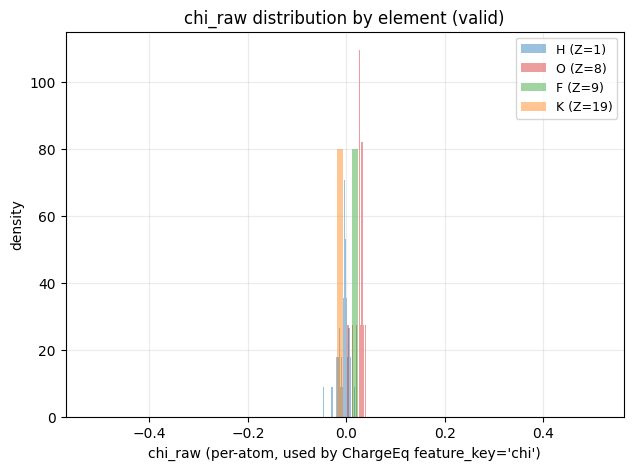

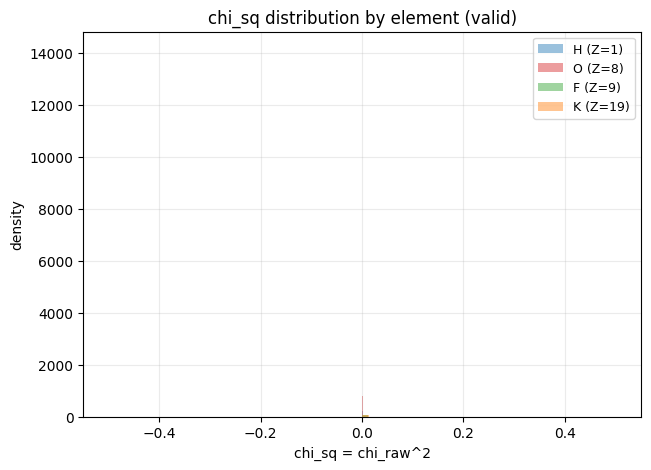

In [30]:
# 6) 按元素查看 chi 分布（valid）：chi_raw 与 chi_sq=chi**2

if "model_path" in globals() and model_path is None:
    print("跳过：未加载 checkpoint。先运行上面的 checkpoint cell 并确保找到 .pth 文件。")
else:
    chi_raw_list, chi_sq_list, z_list = [], [], []

    for batch in valid_loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)

        chi_raw = out["chi"].detach().view(-1).cpu().numpy()
        chi_sq = (out["chi"] ** 2).detach().view(-1).cpu().numpy()
        z = d["atomic_numbers"].detach().view(-1).cpu().numpy()

        chi_raw_list.append(chi_raw)
        chi_sq_list.append(chi_sq)
        z_list.append(z)

    chi_raw_all = np.concatenate(chi_raw_list)
    chi_sq_all = np.concatenate(chi_sq_list)
    z_all = np.concatenate(z_list)

    elem_names = {1: "H", 8: "O", 9: "F", 19: "K"}
    colors = {1: "#1f77b4", 8: "#d62728", 9: "#2ca02c", 19: "#ff7f0e"}

    print("chi_raw min/max:", float(chi_raw_all.min()), float(chi_raw_all.max()))
    print("chi_sq  min/max:", float(chi_sq_all.min()), float(chi_sq_all.max()))

    # 统计：均值/方差（按元素）
    print("\n=== chi stats by element (valid) ===")
    for Z in sorted(set(z_all.tolist())):
        m = z_all == Z
        mu_raw = float(chi_raw_all[m].mean())
        std_raw = float(chi_raw_all[m].std())
        mu_sq = float(chi_sq_all[m].mean())
        std_sq = float(chi_sq_all[m].std())
        print(f"{elem_names.get(int(Z), str(int(Z)))}(Z={int(Z)}): chi_raw mean/std=({mu_raw:.6g},{std_raw:.6g}) | chi_sq mean/std=({mu_sq:.6g},{std_sq:.6g})")

    # 直方图：chi_raw
    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0))
    for Z in sorted(set(z_all.tolist())):
        m = z_all == Z
        ax.hist(
            chi_raw_all[m],
            bins=80,
            density=True,
            alpha=0.45,
            label=f"{elem_names.get(int(Z), str(int(Z)))} (Z={int(Z)})",
            color=colors.get(int(Z), None),
        )
    ax.set_xlabel("chi_raw (per-atom, used by ChargeEq feature_key='chi')")
    ax.set_ylabel("density")
    ax.set_title("chi_raw distribution by element (valid)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    plt.show()

    # 直方图：chi_sq
    fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0))
    for Z in sorted(set(z_all.tolist())):
        m = z_all == Z
        ax.hist(
            chi_sq_all[m],
            bins=80,
            density=True,
            alpha=0.45,
            label=f"{elem_names.get(int(Z), str(int(Z)))} (Z={int(Z)})",
            color=colors.get(int(Z), None),
        )
    ax.set_xlabel("chi_sq = chi_raw^2")
    ax.set_ylabel("density")
    ax.set_title("chi_sq distribution by element (valid)")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    plt.show()


Available keys in model output:
['CACE_energy', 'CACE_forces', 'J_elem', 'J_i', 'SOG_potential', 'SR_energy', 'chi', 'q_eq', 'system_charge', 'tot_chi']

J_i min/max: 0.632394015789032 1.7604244947433472

=== J_i stats by element (valid) ===
H(Z=1): J_i mean/std=(1.06381,0)
O(Z=8): J_i mean/std=(0.632394,0)
F(Z=9): J_i mean/std=(1.04018,0)
K(Z=19): J_i mean/std=(1.76042,0)


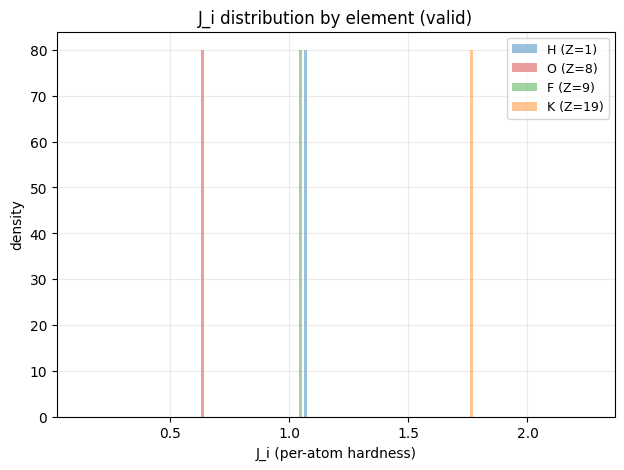


J_elem (by elements order in ChargeEq.elements):
elements: [1, 8, 9, 19]
J_elem: [1.0638112 0.632394  1.0401821 1.7604245]


In [31]:
# 7) 按元素查看硬度 J：优先使用 out['J_i'] / out['J_elem']（若存在）

if "model_path" in globals() and model_path is None:
    print("跳过：未加载 checkpoint。先运行上面的 checkpoint cell 并确保找到 .pth 文件。")
else:
    # 取一个 batch 探测 key
    _batch = next(iter(valid_loader)).to(device)
    _d = _batch.to_dict()
    _d["positions"] = _d["positions"].detach().requires_grad_(True)
    _out = model(_d, training=False)

    print("Available keys in model output:")
    print(sorted(list(_out.keys())))

    if ("J_i" not in _out) and ("J_elem" not in _out):
        print("\n当前输出里没有 J_i / J_elem。")
        print("如果你确定用的是修改后的 cace/modules/charge_eq.py（model_outputs 含 J_i/J_elem），")
        print("但这里仍看不到，通常是因为：checkpoint 来自旧代码版本，或 state_dict 没包含该模块参数。")
    else:
        # 收集 valid 全集的 J_i（每原子）
        J_list, z_list = [], []
        J_elem_last = None

        for batch in valid_loader:
            batch = batch.to(device)
            d = batch.to_dict()
            d["positions"] = d["positions"].detach().requires_grad_(True)
            out = model(d, training=False)

            if "J_i" in out:
                Ji = out["J_i"].detach().view(-1).cpu().numpy()
                J_list.append(Ji)
            if "J_elem" in out:
                J_elem_last = out["J_elem"].detach().view(-1).cpu().numpy()

            z = d["atomic_numbers"].detach().view(-1).cpu().numpy()
            z_list.append(z)

        z_all = np.concatenate(z_list)
        if len(J_list) > 0:
            J_all = np.concatenate(J_list)
            print("\nJ_i min/max:", float(J_all.min()), float(J_all.max()))

            elem_names = {1: "H", 8: "O", 9: "F", 19: "K"}
            colors = {1: "#1f77b4", 8: "#d62728", 9: "#2ca02c", 19: "#ff7f0e"}

            print("\n=== J_i stats by element (valid) ===")
            for Z in sorted(set(z_all.tolist())):
                m = z_all == Z
                mu = float(J_all[m].mean())
                std = float(J_all[m].std())
                print(f"{elem_names.get(int(Z), str(int(Z)))}(Z={int(Z)}): J_i mean/std=({mu:.6g},{std:.6g})")

            fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0))
            for Z in sorted(set(z_all.tolist())):
                m = z_all == Z
                ax.hist(
                    J_all[m],
                    bins=80,
                    density=True,
                    alpha=0.45,
                    label=f"{elem_names.get(int(Z), str(int(Z)))} (Z={int(Z)})",
                    color=colors.get(int(Z), None),
                )
            ax.set_xlabel("J_i (per-atom hardness)")
            ax.set_ylabel("density")
            ax.set_title("J_i distribution by element (valid)")
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=9)
            plt.show()

        if J_elem_last is not None:
            print("\nJ_elem (by elements order in ChargeEq.elements):")
            print("elements:", elements)
            print("J_elem:", J_elem_last)


Total atoms(valid): 194
q_ref  min/max: -1.0 1.0
q_pred min/max: -0.04873601719737053 0.04280043765902519


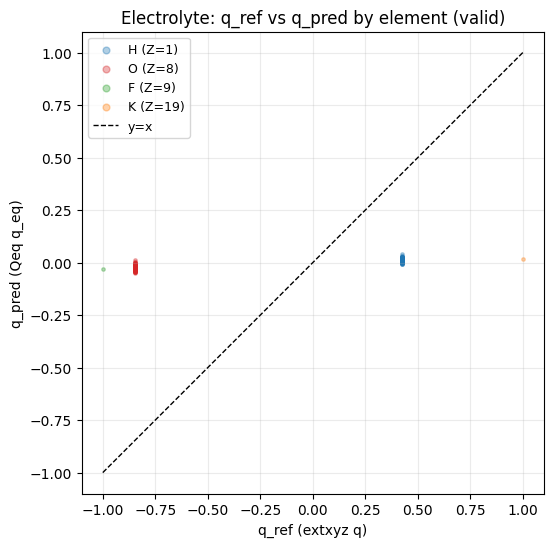

In [32]:
# 5) 计算电荷：按元素画 q_ref vs q_pred 散点图

if "model_path" in globals() and model_path is None:
    print("跳过：未加载 checkpoint。先运行上一格并确保找到 .pth 文件。")
else:
    q_pred_list, q_ref_list, z_list = [], [], []

    for batch in valid_loader:
        batch = batch.to(device)
        d = batch.to_dict()
        # 电荷不需要 Forces 的梯度，但模型里含 Forces，为避免 Forces 触发 autograd，
        # 这里仍然给 positions 设 requires_grad=True（开销可接受）。
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)

        q_pred = out["q_eq"].detach().view(-1).cpu().numpy()
        q_ref  = d["charge"].detach().view(-1).cpu().numpy()
        z      = d["atomic_numbers"].detach().view(-1).cpu().numpy()

        q_pred_list.append(q_pred)
        q_ref_list.append(q_ref)
        z_list.append(z)

    q_pred_all = np.concatenate(q_pred_list)
    q_ref_all  = np.concatenate(q_ref_list)
    z_all      = np.concatenate(z_list)

    print("Total atoms(valid):", len(q_pred_all))
    print("q_ref  min/max:", float(q_ref_all.min()), float(q_ref_all.max()))
    print("q_pred min/max:", float(q_pred_all.min()), float(q_pred_all.max()))

    elem_names = {1: "H", 8: "O", 9: "F", 19: "K"}
    colors = {1: "#1f77b4", 8: "#d62728", 9: "#2ca02c", 19: "#ff7f0e"}

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 6))
    for Z in sorted(set(z_all.tolist())):
        mask = z_all == Z
        ax.scatter(
            q_ref_all[mask],
            q_pred_all[mask],
            s=6,
            alpha=0.35,
            label=f"{elem_names.get(int(Z), str(int(Z)))} (Z={int(Z)})",
            color=colors.get(int(Z), None),
        )

    mn = float(min(q_ref_all.min(), q_pred_all.min()))
    mx = float(max(q_ref_all.max(), q_pred_all.max()))
    ax.plot([mn, mx], [mn, mx], "k--", lw=1, label="y=x")
    ax.set_xlabel("q_ref (extxyz q)")
    ax.set_ylabel("q_pred (Qeq q_eq)")
    ax.set_title("Electrolyte: q_ref vs q_pred by element (valid)")
    ax.grid(True, alpha=0.25)
    ax.legend(markerscale=2, fontsize=9)
    ax.set_aspect("equal", adjustable="box")
    plt.show()


chi min/max: -0.053650424 0.04017589


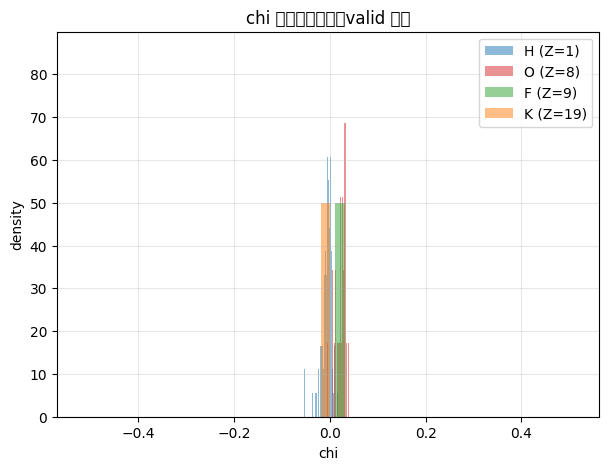

In [33]:
# 6) 查看 chi 分布（valid 集）
chi_list = []
z_list_chi = []
for batch in valid_loader:
    batch = batch.to(device)
    d = batch.to_dict()
    d["positions"] = d["positions"].detach().requires_grad_(True)
    out = model(d, training=False)
    chi_batch = out["chi"].detach().view(-1).cpu().numpy()        # (N_atoms,)
    z_batch   = d["atomic_numbers"].detach().view(-1).cpu().numpy()
    chi_list.append(chi_batch)
    z_list_chi.append(z_batch)
chi_all = np.concatenate(chi_list)
z_all_chi = np.concatenate(z_list_chi)
print("chi min/max:", chi_all.min(), chi_all.max())
elem_names = {1: "H", 8: "O", 9: "F", 19: "K"}
colors = {1: "#1f77b4", 8: "#d62728", 9: "#2ca02c", 19: "#ff7f0e"}
plt.figure(figsize=(7, 5))
for Z in sorted(set(z_all_chi.tolist())):
    mask = z_all_chi == Z
    plt.hist(
        chi_all[mask],
        bins=50,
        alpha=0.5,
        density=True,
        label=f"{elem_names.get(int(Z), str(int(Z)))} (Z={int(Z)})",
        color=colors.get(int(Z), None),
    )
plt.xlabel("chi")
plt.ylabel("density")
plt.title("chi 分布（按元素，valid 集）")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()